# Notebook OBjectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
import json, os, jax, glob
import jax.numpy as jnp
import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np
from pyscripts.analysis import NN_Experiment_Analyzer
import pyscripts.jax_amber3 as jaa

jax:    0.4.28
jaxlib: 0.4.28
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [cuda(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='genuinelyjollyjackalope', release='6.5.0-35-generic', version='#35~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May  7 09:00:52 UTC 2', machine='x86_64')


$ nvidia-smi
Wed May 22 15:52:42 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|==========================

In [2]:
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

gas_fun, _ = jaa.get_amber_functions('Simulation/ala_deca_peptide.prmtop')
def scaled_pot_enr_diff(a, b, potential_coefficient=None): # WITH A AS BATCH AND B AS RECON
    return ((gas_fun(a) - gas_fun(b))/gas_fun(a))**2 #Unitless quantity

class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str]):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = NN_Experiment_Analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        figure(figsize=(3.25, 3), dpi=80)
        plt.rc('font', **{'family' : 'normal', 'weight' : 'bold', 'size'   : 11})
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()

    def potential_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, pots = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            pots.append(jax.jit(scaled_pot_enr_diff)(exp.test_data, recon))
        latents, pots = jnp.array(latents), jnp.array(pots)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(jnp.sqrt(pots), pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('Potential Deviation (%)')
        plt.yscale('log')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

2024-05-22 15:52:45.284695: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
rpt = 3
bromo_cards = [f'bridges2_runs/5_20_24/jsons/3mxf_*{rpt}.json',
               f'bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
dapot_cards = [f'bridges2_runs/5_15_24/jsons/*{rpt}.json',
               f'bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
darmsd_cards = [f'bridges2_runs/4_24_24/jsons/DA*{rpt}.json',
                f'bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
crrmsd_cards = [f'bridges2_runs/4_24_24/jsons/Crambin_AE_*{rpt}.json',
                f'bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']



json_wildcard, nc_wildcard, ckpt_wildcard = dapot_cards
json_fns = sorted(glob.glob(json_wildcard))
netcdf_fns = sorted(glob.glob(nc_wildcard))
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))
checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [4]:
for i in range(len(json_fns)):
    print(json_fns[i])
    print(netcdf_fns[i])
    print(checkpoint_dirs[i])
    print('#########################################################')

bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0001_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0001_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0001_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0001_latents/rpt_3/checkpoint_managed/2000/default/
#########################################################
bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0002_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0002_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0002_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0002_latents/rpt_3/checkpoint_managed/2400/default/
#########################################################
bridges2_runs/5_15_24/jsons/DA_AE_Dropout_RMSD_and_Scale_0004_3.json
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0004_latents/rpt_3/model_DA_AE_Dropout_RMSD_and_Scale_0004_checkpoint.nc
bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/0004_latents/rpt_3/checkpoint_managed/6800/defau

In [5]:
json_params_series = []
for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Joseph-Large/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [6]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs)

Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop', 'fname_pdb': 'None', 'save_dir': '/media/volume/Joseph-Large/githubs/Deep-MMS/', 'data_dir': 'None', 'max_epoch': 100000, 'latent_dim': 1, 'test_slice': 3, 'data_slice_start': 0, 'data_slice_end': 'None', 'model_name': 'DA_AE_Dropout_RMSD_and_Scale', 'batch_size': 2000, 'learning_rate': 1e-06, 'dropout_rates': [0.1, 0.1, 0.1], 'potential_threshold': 10, 'model_type': 'AE', 'coordinate_scheme': 'Cartesian', 'resume_latest': False, 'report_potential': True, 'checkpoint_interval': 200}
Load Data with MDTraj
Batch data
(8000, 306) (2000, 306)
Model Init
Batch Data
Read NetCDF and Checkpoint
Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide

In [ ]:
def plot_results(exp):
    traingrp = exp.rootgrp['Train']
    testgrp = exp.rootgrp['Test']
    keys = ['RMSD']
    plt.clf()
    plt.title('RMSD' + f' {exp.n_latents} Latents')
    for grp in [traingrp, testgrp]:
        _ = plt.plot(np.arange(grp.variables['RMSD'][:, :].shape[0]),
                     np.mean(grp.variables['RMSD'][:, :], axis=1))
    plt.xlabel('Epoch')
    plt.ylabel('RMSD (nm)')
    plt.legend(['Train','Test'])
    plt.show()

    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')

In [ ]:
for key, exp in self.experiments.items():
    print(key, exp)
    plot_results(exp)

2 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f96840>


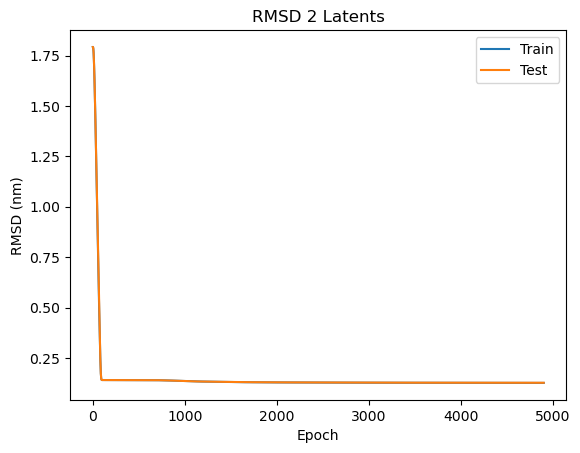

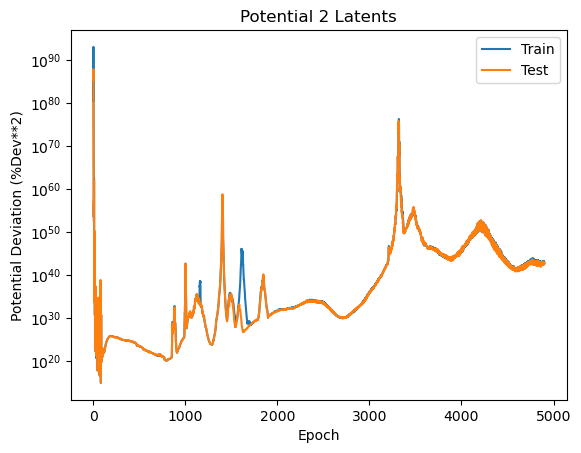

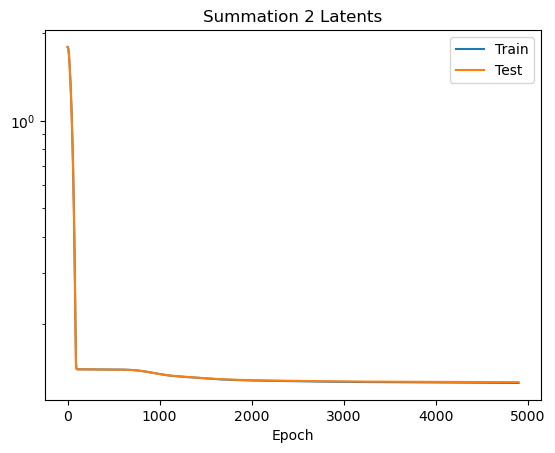

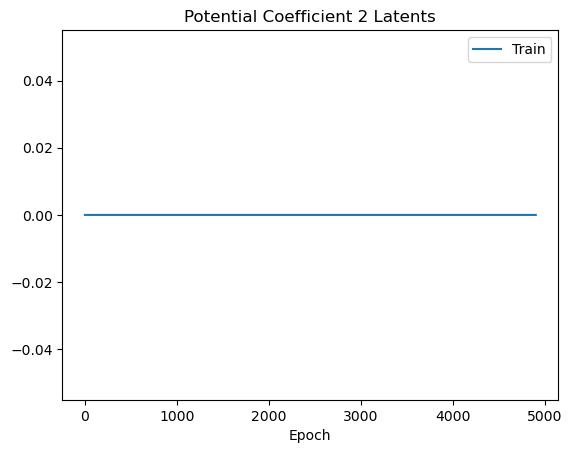

Num Epochs 4900
Last RMSD (nm): Train: 0.1257399022579193 Test 0.12655019760131836
Last PotDiff (% Deviation): Train: 5.659650940230898e+42 Test 3.9491707471973114e+42
4 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3875d9be0>


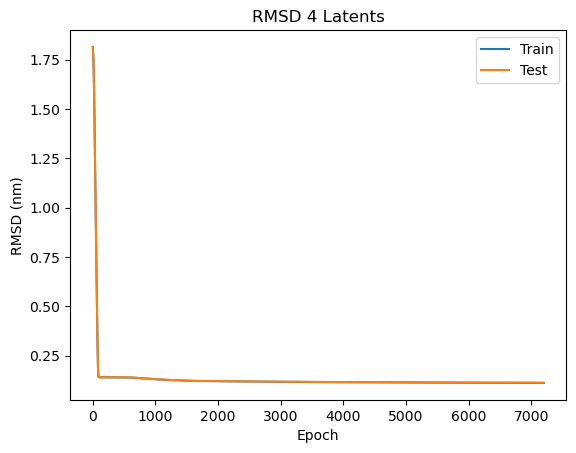

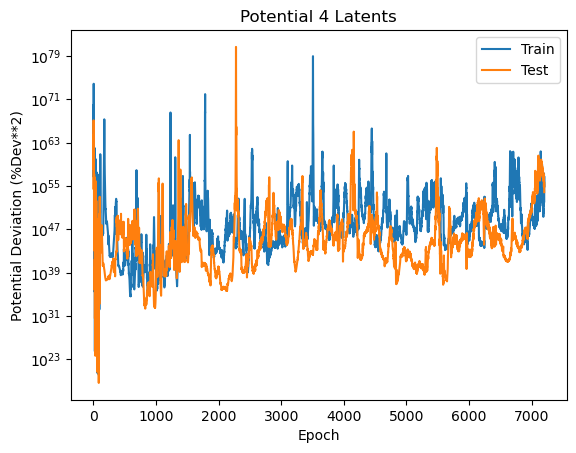

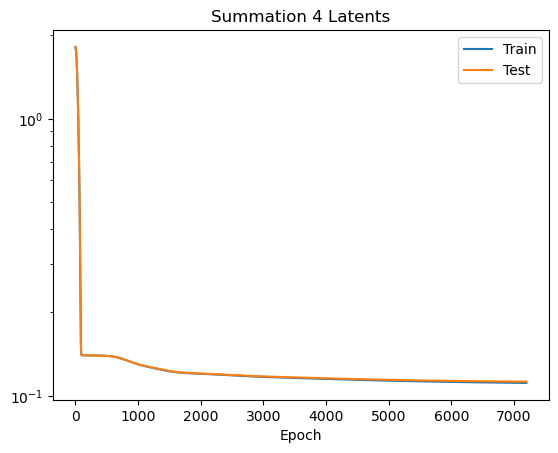

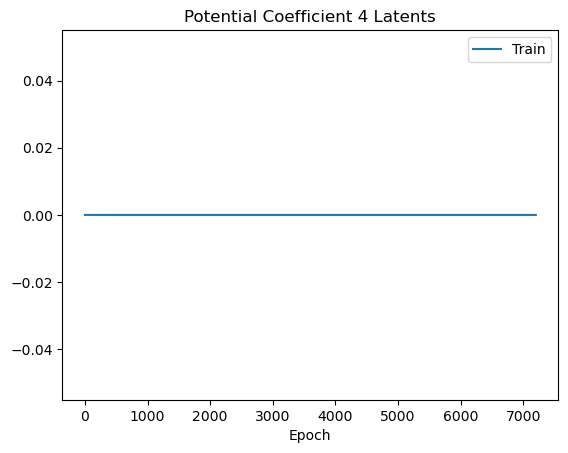

Num Epochs 7200
Last RMSD (nm): Train: 0.11131574958562851 Test 0.1124827116727829
Last PotDiff (% Deviation): Train: 1.4418465648826285e+52 Test 7.3297784203220175e+53
8 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be1003e0>


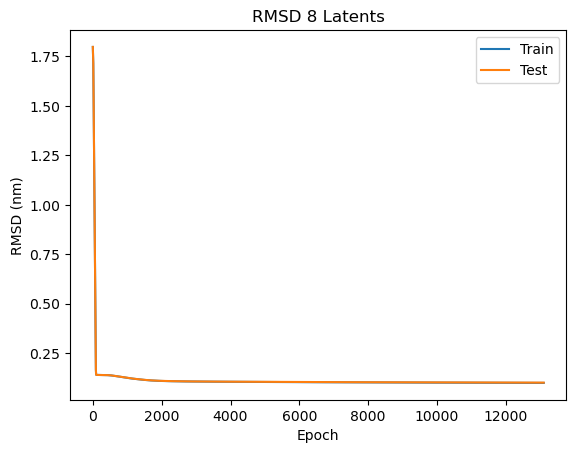

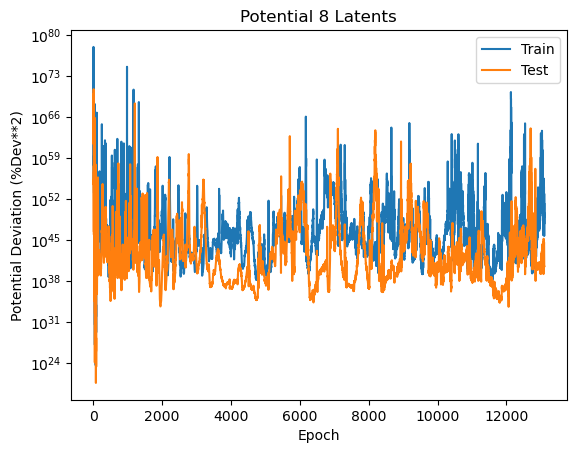

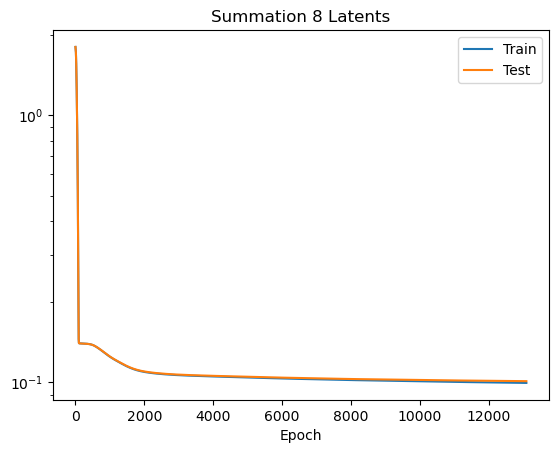

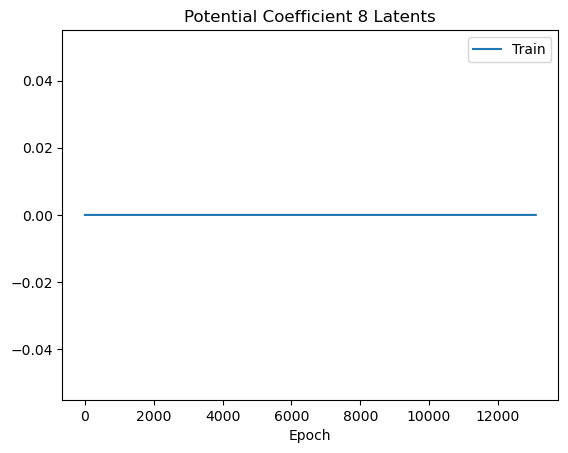

Num Epochs 13100
Last RMSD (nm): Train: 0.09961971640586853 Test 0.10113857686519623
Last PotDiff (% Deviation): Train: 1.5549167868322698e+51 Test 3.2089523912779553e+40
16 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be11e9c0>


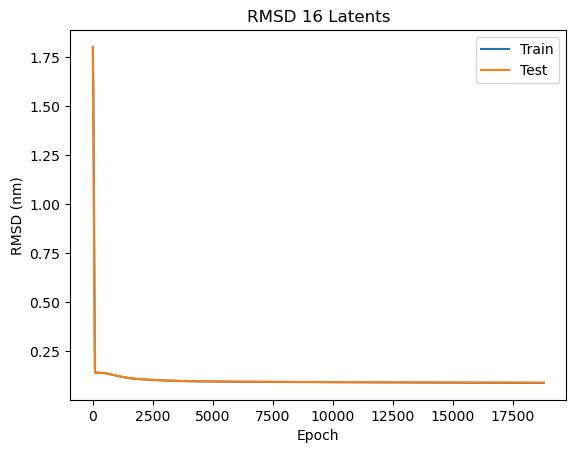

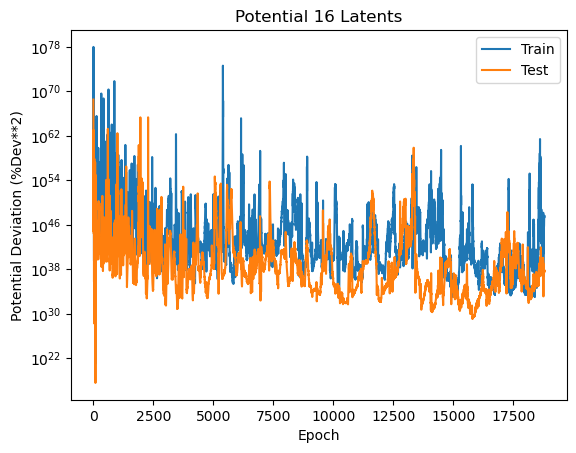

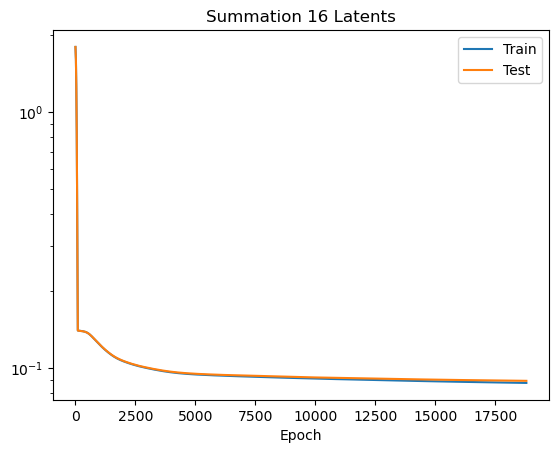

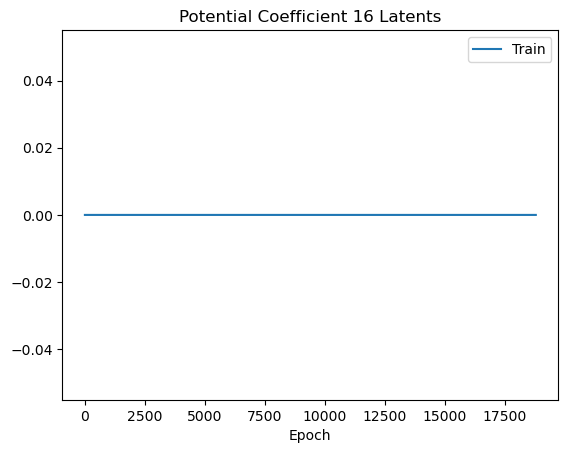

Num Epochs 18800
Last RMSD (nm): Train: 0.08736182749271393 Test 0.0890246033668518
Last PotDiff (% Deviation): Train: 3.80742623568354e+47 Test 5.147773466261213e+37
32 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398cc0410>


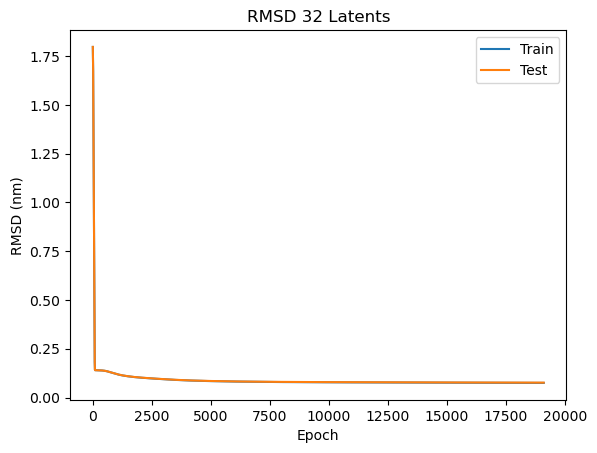

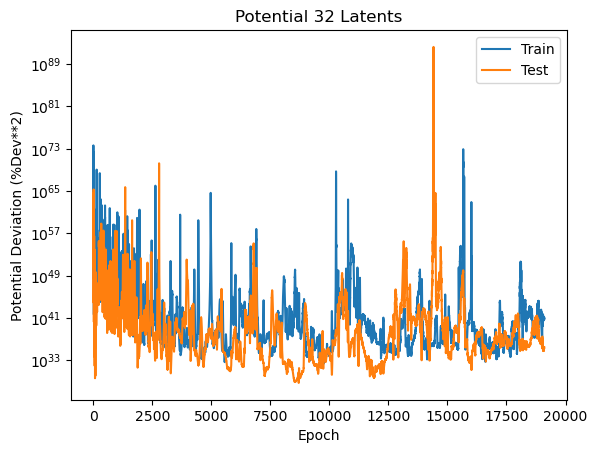

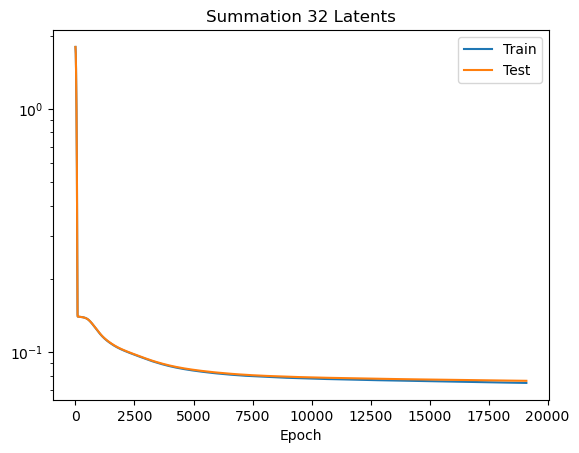

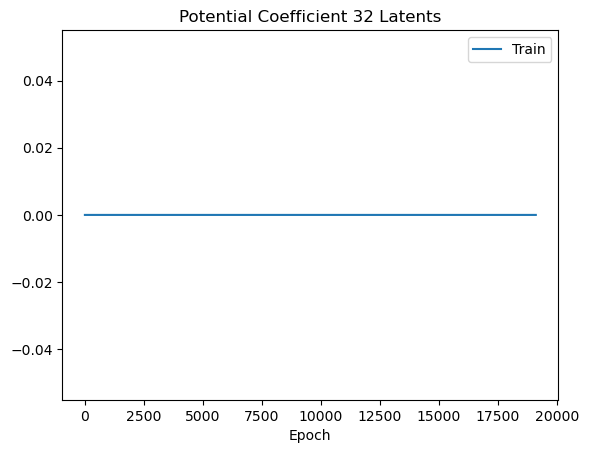

Num Epochs 19100
Last RMSD (nm): Train: 0.07473844289779663 Test 0.07625354826450348
Last PotDiff (% Deviation): Train: 8.133197836468415e+40 Test 2.7993928726109764e+35
64 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1b8d520>


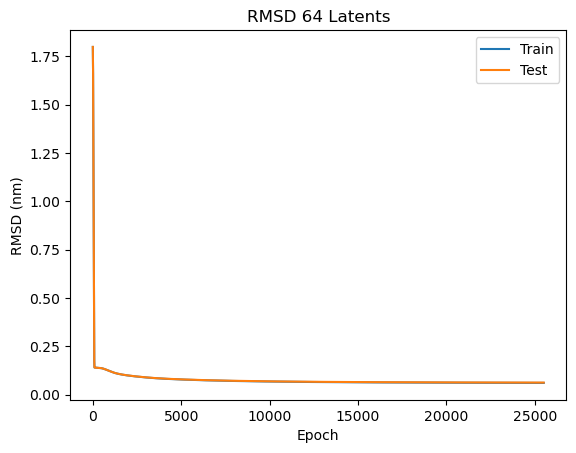

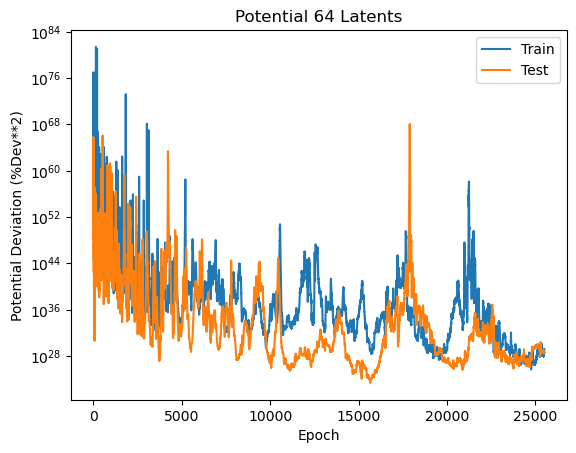

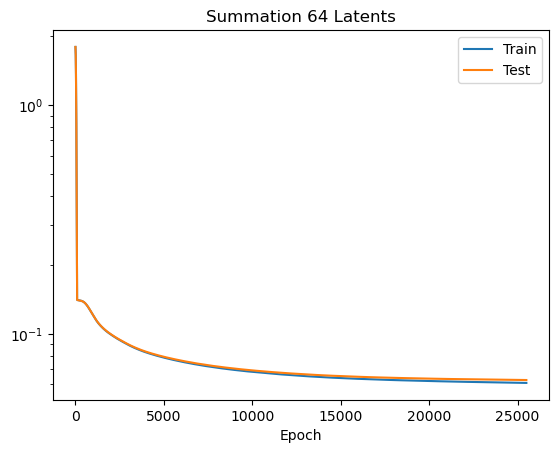

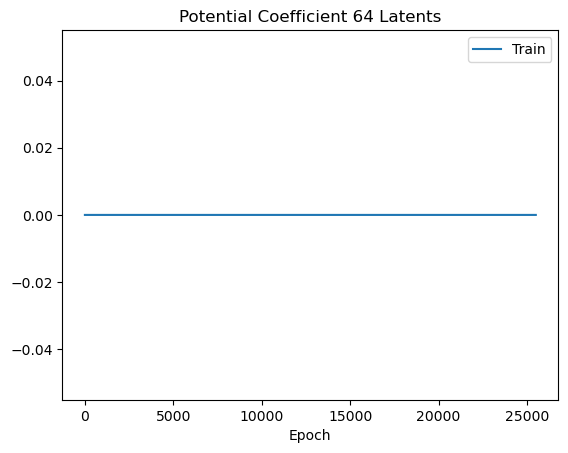

Num Epochs 25500
Last RMSD (nm): Train: 0.06078379601240158 Test 0.06258763372898102
Last PotDiff (% Deviation): Train: 1.4944148643733325e+29 Test 3.735667822781987e+28
128 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3866d5820>


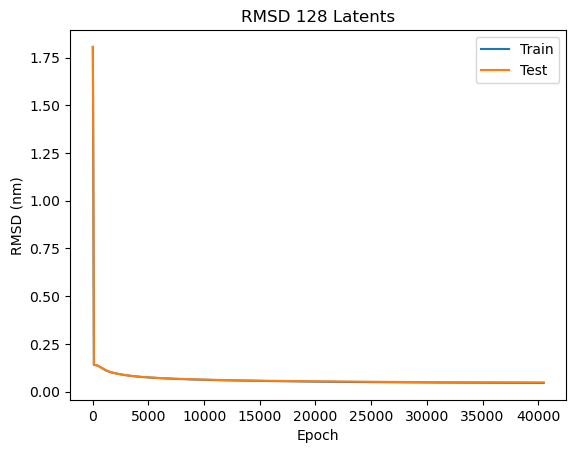

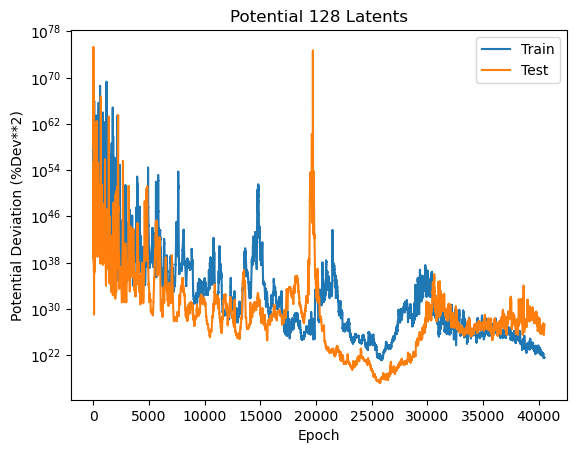

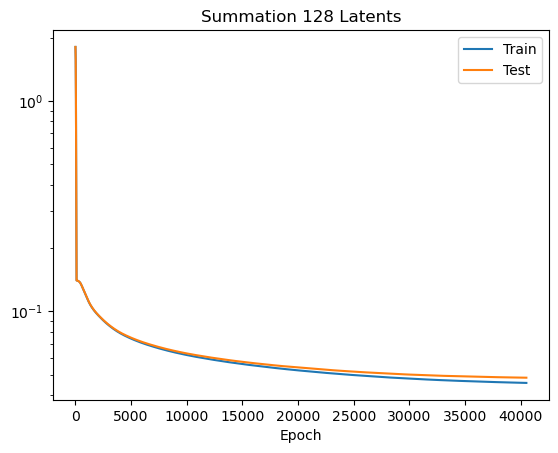

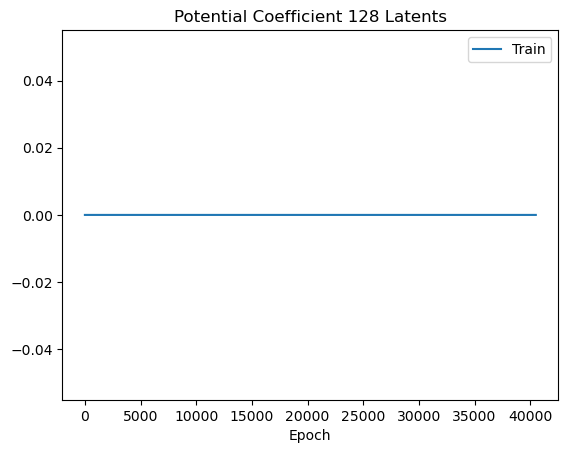

Num Epochs 40500
Last RMSD (nm): Train: 0.04564692825078964 Test 0.04833317548036575
Last PotDiff (% Deviation): Train: 3.5965917907749506e+21 Test 1.5172769988532677e+27
256 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3849eefc0>


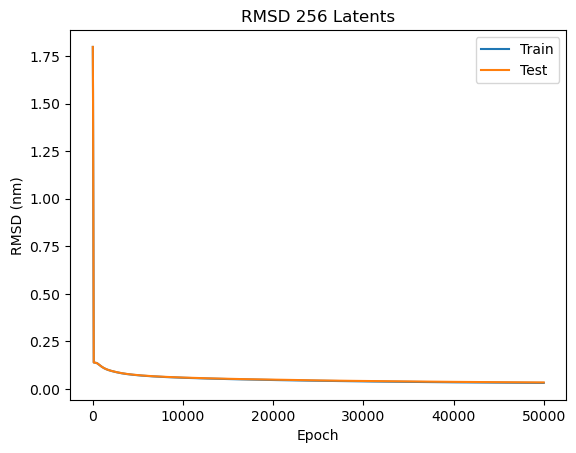

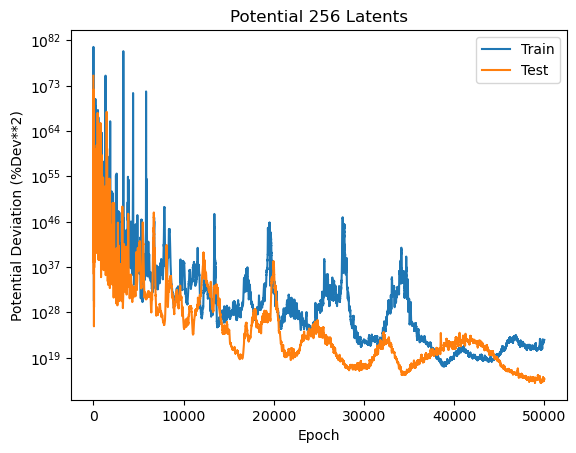

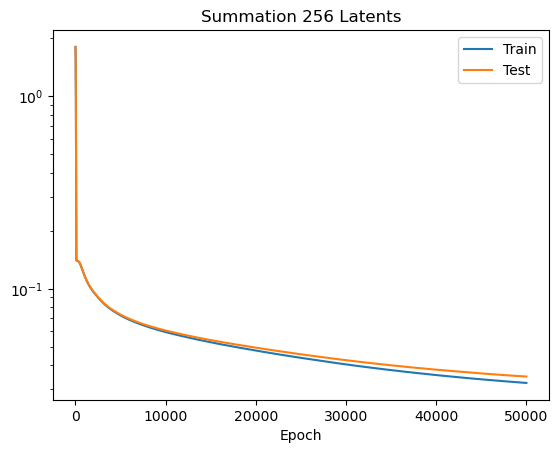

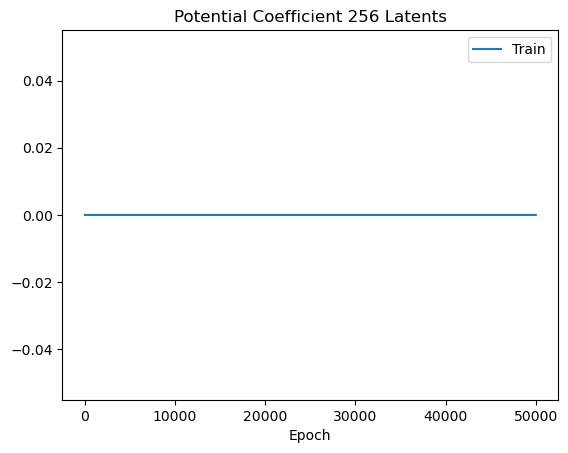

Num Epochs 50000
Last RMSD (nm): Train: 0.03238418698310852 Test 0.034947849810123444
Last PotDiff (% Deviation): Train: 3.3151555206683914e+22 Test 579200075155293.4
512 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f14950>


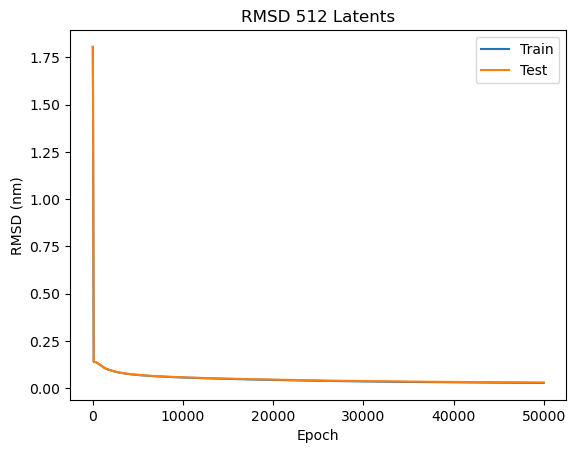

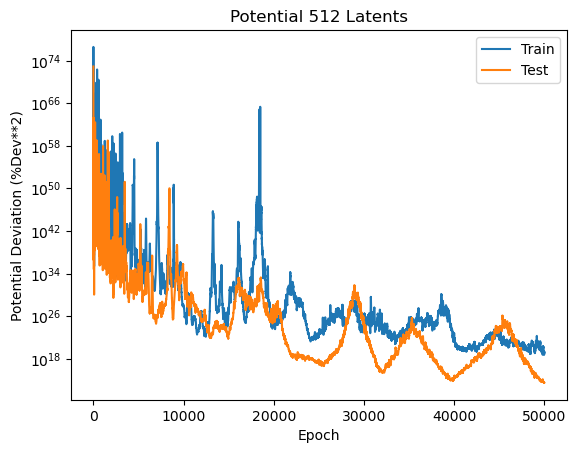

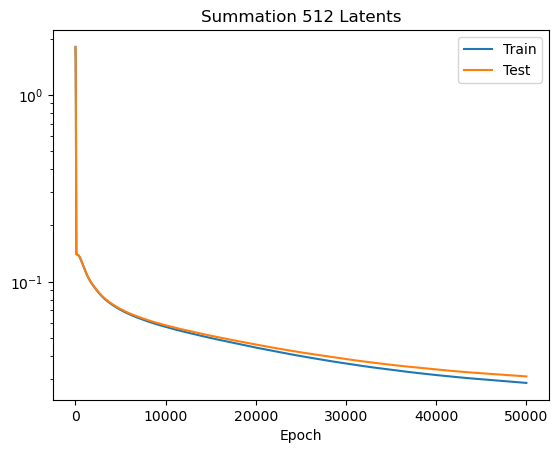

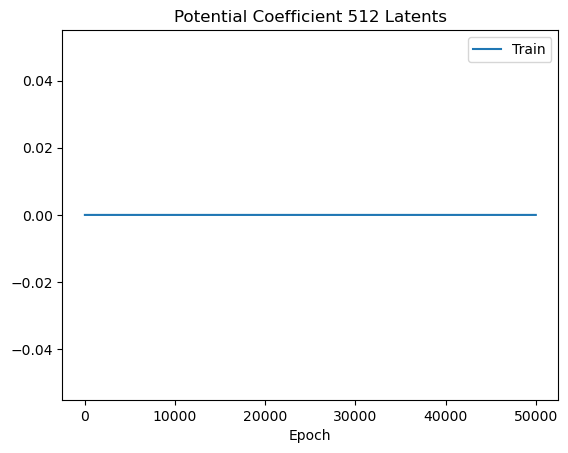

Num Epochs 50000
Last RMSD (nm): Train: 0.02863680198788643 Test 0.031026119366288185
Last PotDiff (% Deviation): Train: 1.982344177585922e+19 Test 31844474923870.656
1024 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c386ee7d10>


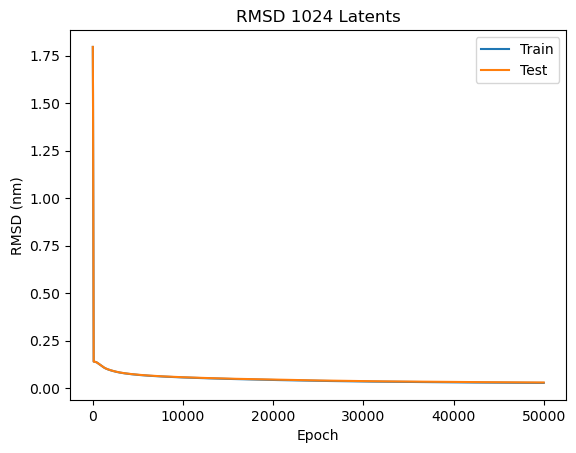

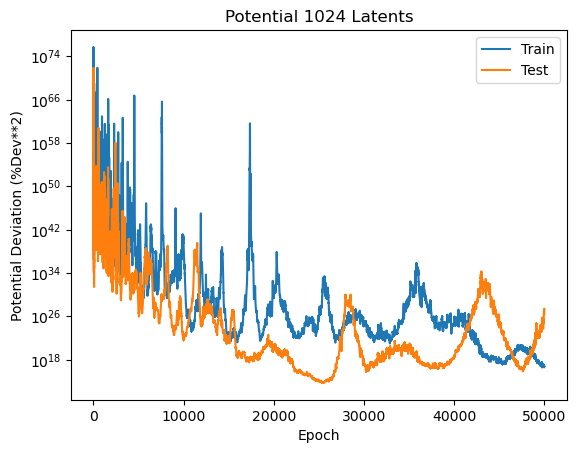

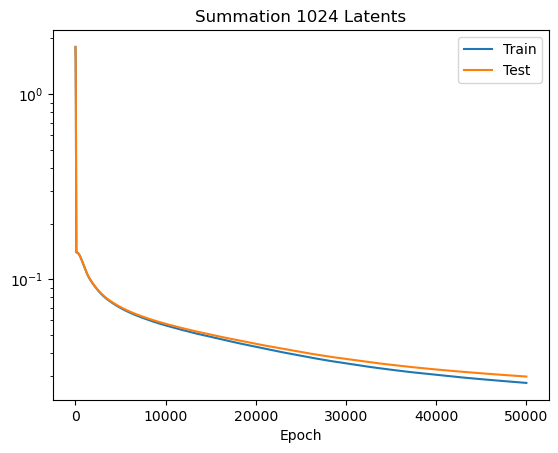

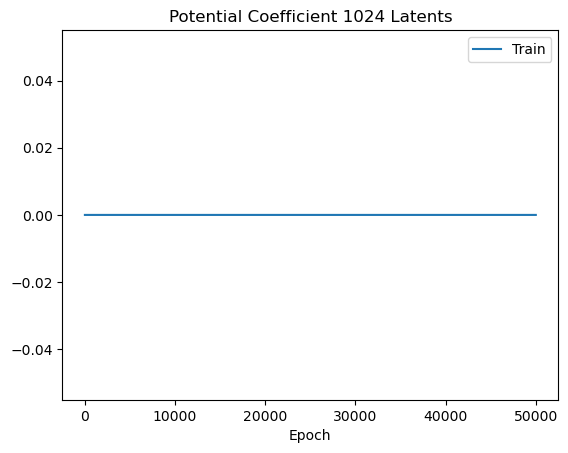

Num Epochs 50000
Last RMSD (nm): Train: 0.027588985860347748 Test 0.029860351234674454
Last PotDiff (% Deviation): Train: 6.12582525655136e+16 Test 2.3335940071162356e+27
1926 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398d455e0>


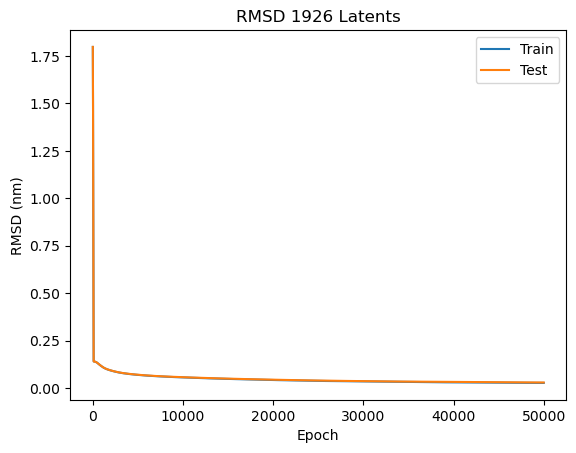

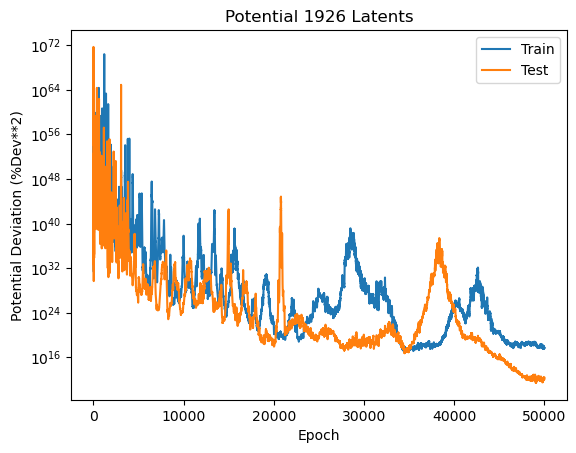

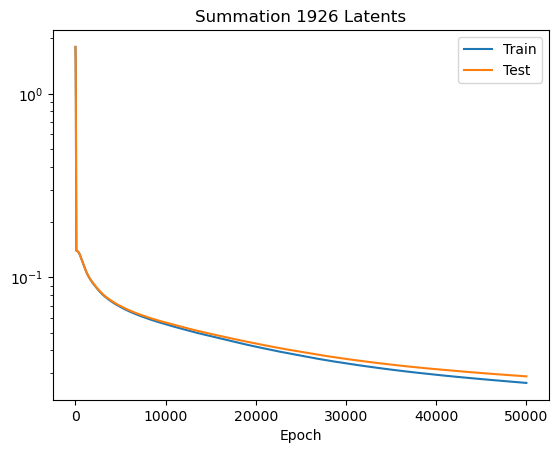

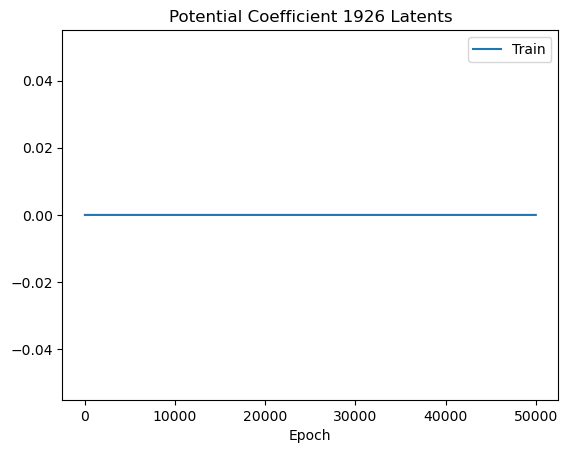

Num Epochs 50000
Last RMSD (nm): Train: 0.026587123051285744 Test 0.028869254514575005
Last PotDiff (% Deviation): Train: 4.990994141151783e+17 Test 2080813244902.465


In [7]:
for key, exp in self.experiments.items():
    print(key, exp)
    exp.plot_results()

In [ ]:
def rmsd_violin_plot(self, rng_seed, title):
    #Assemble the Data
    latents, rmsds = [], []
    for key, exp in self.experiments.items():
        latents.append(exp.n_latents)
        recon, _ = exp.operate(rng_seed)
        rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
    latents, rmsds = jnp.array(latents), jnp.array(rmsds)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    plt.title(title)
    plt.ylabel('RMSD (Angstrom)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

In [ ]:
rmsd_violin_plot(self, rng_seed=98263, title='RMSD Error - Bromodomains')

In [ ]:
self.potential_violin_plot(rng_seed=98263, title='Potential Energy Error upon Reconstruction - DecaAlanine')

In [7]:
model = self.experiments['4 Latents']
rng_seed = 92183

In [8]:
test_data = model.test_data
recon, _ = model.operate(rng_seed)
_, samples_5 = model.gaussian_mm_fit(rng_seed, 5)

In [9]:
test_ener = gas_fun(test_data)
recon_ener = gas_fun(recon)
ener_5 = gas_fun(model.decode(rng_seed, samples_5))

Outliers above 1000.0 kJ/mol for 4 Latents - 5 Components: 74 (3.7 %)
Outliers above 1000.0 kJ/mol for 4 Latents - 5 Components: 86 (4.3 %)


<Figure size 640x480 with 0 Axes>

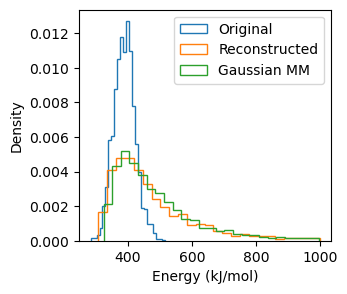

In [10]:
plt.clf()
plt.figure(figsize=(3.25, 3))
threshold = 1e3
plt.hist(test_ener, histtype='step', bins=25, density=True)

num_outliers_recon = recon_ener[recon_ener > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_recon} ({100*num_outliers_recon/2000} %)")
plt.hist(recon_ener[recon_ener < threshold], histtype='step', bins=25, density=True)

num_outliers_5 = ener_5[ener_5 > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_5} ({100*num_outliers_5/2000} %)")
plt.hist(ener_5[ener_5 < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(['Original', 'Reconstructed', 'Gaussian MM'])
plt.ylabel('Density')
plt.savefig(f'DA_4_latents_GMM_ener.png', dpi=600, bbox_inches = "tight")
plt.show()

In [ ]:
test, decoded, generated = model.test_decoded_modeled_trajs(rng_seed, 5)

In [ ]:
#Cluster the generated
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
clusters = []
for i in range(2, 10):
    clusters.append(i)
    kmeans = KMeans(n_clusters=i).fit_predict(generated)
    sil_scores.append(silhouette_score(generated, kmeans))

sil_scores = np.array(sil_scores)
clusters = np.array(clusters)


plt.clf()
_ = plt.plot(clusters, sil_scores)
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(generated)

In [ ]:
plt.clf()
_ = plt.hist(jnp.log10(gas_fun(generated)), bins=25, histtype='step', density=True)
_ = plt.hist(jnp.log10(gas_fun(test)), bins=25, histtype='step', density=True)
plt.show()

gas_fun(kmeans.cluster_centers_)

In [8]:
model = self.experiments['16 Latents']

In [27]:
variance = lambda x: jnp.sum((x - jnp.mean(x))**2)/x.shape[0]
std_dev = lambda x: jnp.sqrt(variance(x))

def divvy_pdevs(pdevs, n_move):
    return jnp.array([pdevs[i-n_move:i] for i in range(n_move, pdevs.shape[0])])

def calculate_variance_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(variance, in_axes=(0))(pdevs_div)

def calculate_stddev_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(std_dev, in_axes=(0))(pdevs_div)

2 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f96840>


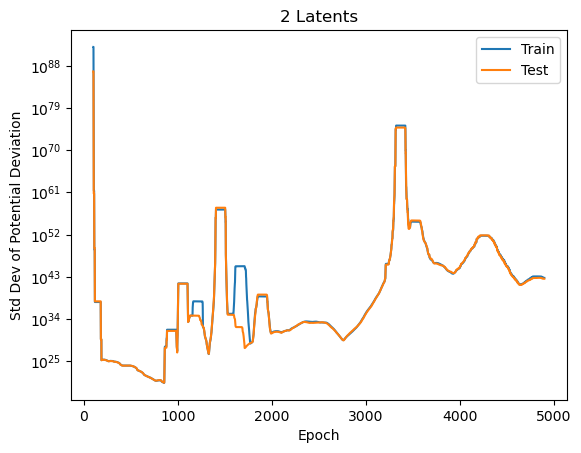

4 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3875d9be0>


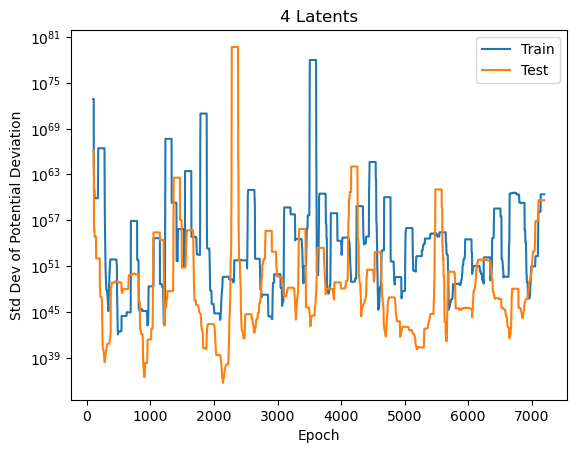

8 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be1003e0>


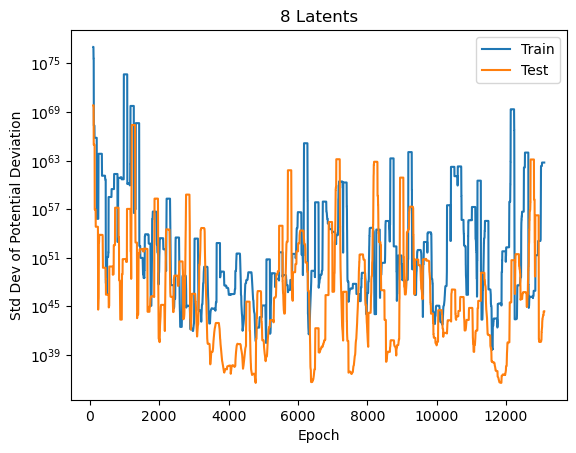

16 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be11e9c0>


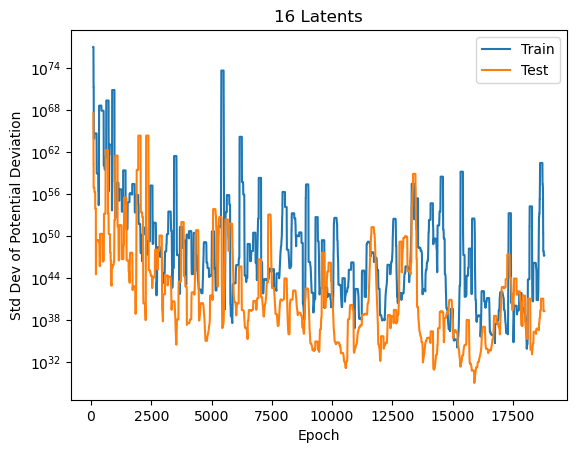

32 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398cc0410>


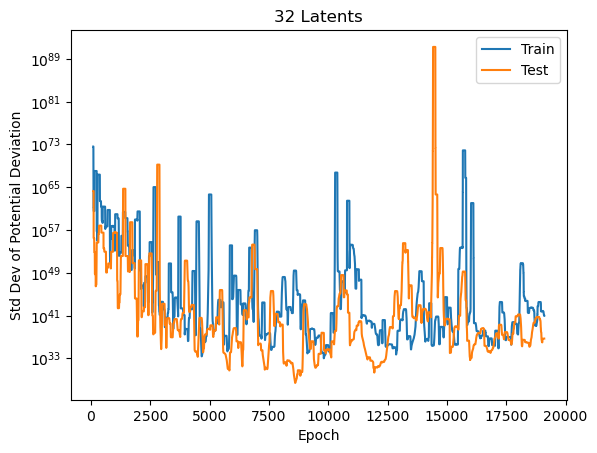

64 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1b8d520>


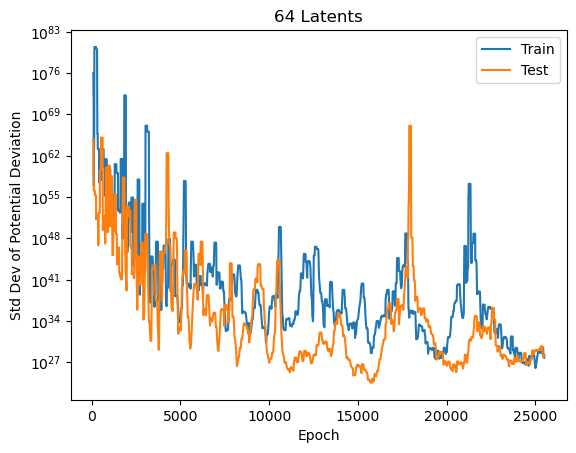

128 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3866d5820>


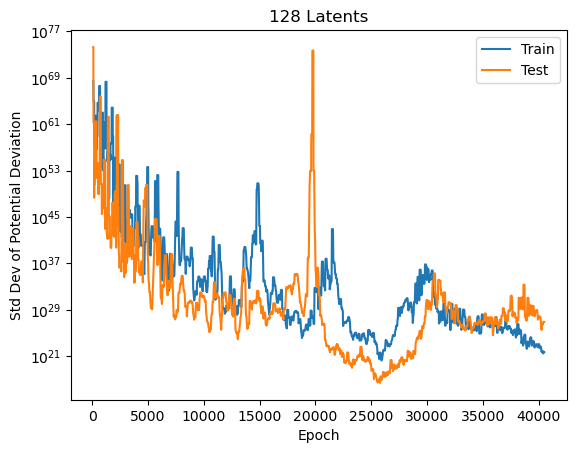

256 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3849eefc0>


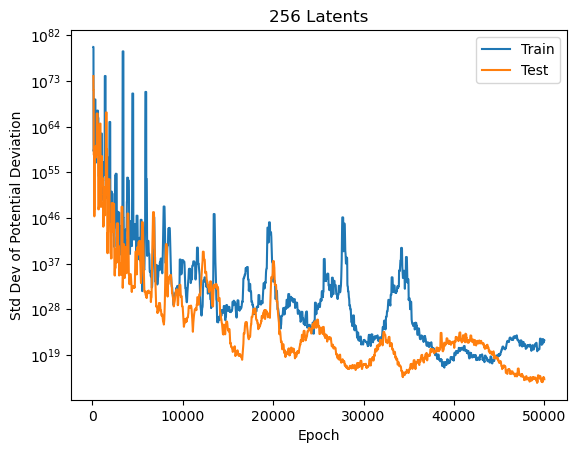

512 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f14950>


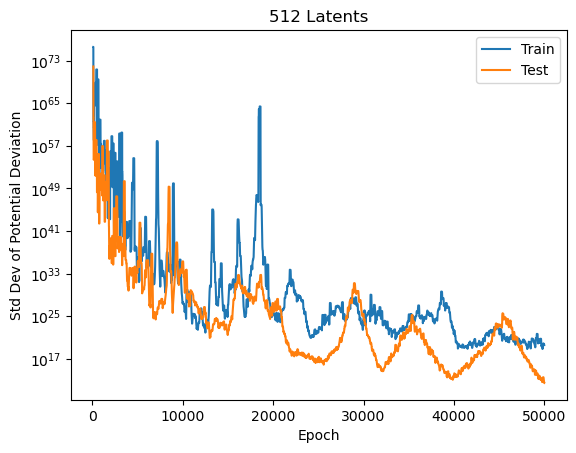

1024 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c386ee7d10>


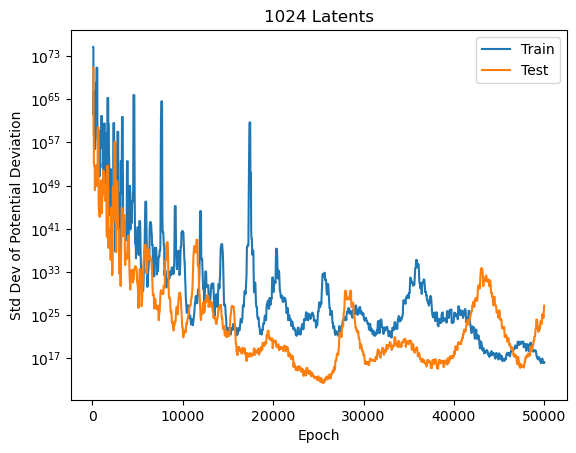

1926 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398d455e0>


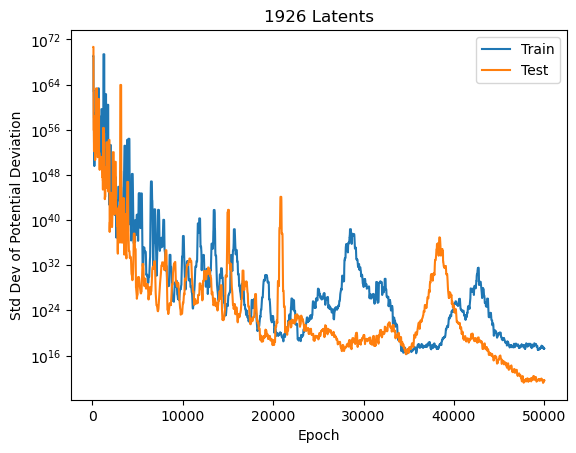

In [31]:
n_move = 100

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.legend(['Train', 'Test'])
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.savefig(f'std_dev_of_potential_deviation_{key}.png')
    plt.show()    

In [ ]:
n_move = 10

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.show()

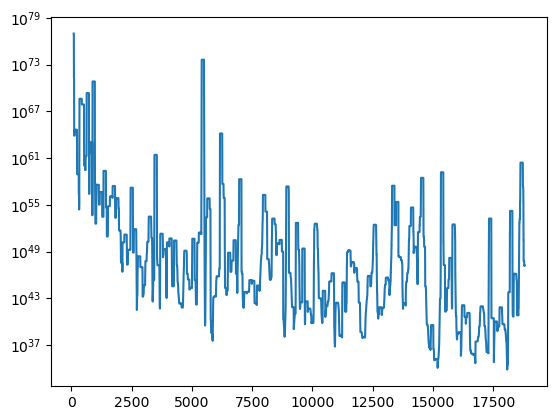

In [13]:
plt.clf()
_ = plt.plot(jnp.arange(100, vars.shape[0]+100), jnp.sqrt(vars))
plt.yscale('log')
plt.show()

In [ ]:
fname = f'{model.model_name}{model.n_latents:04d}_GMM_sample_cluster_centers.dcd'
traj_xyz = kmeans.cluster_centers_.reshape(kmeans.cluster_centers_.shape[0], -1, 3)
with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10)

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Double Digits Latents
plt.clf()
n_latents = 100
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Triple Digits Latents
plt.clf()
n_latents = 1000
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        _, samples = exp.gaussian_mm_fit(rng_seed, 5)
        recon = exp.decode(rng_seed, samples)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
A, B = self.super_traj_construct()

In [ ]:
rmsd = jax.vmap(atom_rmsd)(A, B)

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [ ]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [ ]:
#Write a PDB for visualization with OpenMM

In [ ]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [ ]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')

In [ ]:
positions = A[0, :].reshape(-1, 3)

In [ ]:
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)